In [1]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
from datetime import timedelta
from typing import Callable, Dict, List, Optional, Tuple

Définition d’une structure de paramètres globale qui centralise les ressources (nombre de boxes, durée moyenne de prise en charge, mode d’ordonnancement et noms de colonnes).

In [2]:
@dataclass(frozen=True)
class SimParams:
    n_boxes: int
    box_service_duration: pd.Timedelta
    mode_ordonnancement: str
    col_arrival: str = "_informations_du_passage_date_et_heure_darrive"
    col_patient_id: str = "num_dordre"

Déclaration de l’interface de la fonction ordonner, qui sera fournie par les autres membres du projet.

In [17]:
def ordonner(df: pd.DataFrame, mode: str) -> pd.DataFrame:
    if mode != "fifo":
        raise ValueError("Mode non supporté pour ce test. Utiliser mode='fifo'.")
    
    return df.sort_values(
        "_informations_du_passage_date_et_heure_darrive",
        kind="mergesort"
    ).reset_index(drop=True)

Chargement du fichier CSV des patients et préparation des colonnes essentielles (conversion en datetime et nettoyage minimal).

In [4]:
def load_patients(csv_path: str, params: SimParams) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df[params.col_arrival] = pd.to_datetime(df[params.col_arrival], errors="coerce")
    df = df.dropna(subset=[params.col_arrival, params.col_patient_id]).copy()
    df[params.col_patient_id] = df[params.col_patient_id].astype(str)
    return df

Filtrage des patients selon la plage horaire de simulation et tri chronologique par heure d’arrivée.

In [5]:
def filter_patients_by_window(df: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp, params: SimParams) -> pd.DataFrame:
    out = df[(df[params.col_arrival] >= start) & (df[params.col_arrival] <= end)].copy()
    out = out.sort_values(params.col_arrival, kind="mergesort").reset_index(drop=True)
    return out

Initialisation de la structure des boxes avec leur état initial (tous libres au début --> supposition idéale).

In [6]:
def init_boxes(params: SimParams) -> pd.DataFrame:
    boxes = pd.DataFrame({"ID_box": [f"box_{i+1}" for i in range(params.n_boxes)]})
    boxes["t"] = pd.NaT
    boxes["debut_occupation"] = pd.NaT
    boxes["fin_occupation"] = pd.NaT
    boxes["ID_patient"] = pd.NA
    boxes["status"] = "free"
    return boxes

Fonction interne permettant d’identifier le prochain événement de libération d’un box occupé.

In [7]:
def _next_release_time(boxes: pd.DataFrame) -> Optional[pd.Timestamp]:
    occ = boxes[boxes["status"] == "busy"]
    if occ.empty:
        return None
    t = occ["fin_occupation"].min()
    if pd.isna(t):
        return None
    return pd.Timestamp(t)

Mise à jour de l’état des boxes au moment t : libération des boxes dont la prise en charge est terminée et enregistrement des données correspondantes.

In [8]:
def _free_boxes_at_time(
    boxes: pd.DataFrame,
    t: pd.Timestamp,
    service_log: List[Dict],
    box_histories: Dict[str, List[Dict]]
) -> None:
    mask = (boxes["status"] == "busy") & (boxes["fin_occupation"] <= t)
    if not mask.any():
        boxes["t"] = t
        return

    for idx, row in boxes[mask].iterrows():
        rec = {
            "ID_box": row["ID_box"],
            "ID_patient": str(row["ID_patient"]),
            "debut_occupation": pd.Timestamp(row["debut_occupation"]),
            "fin_occupation": pd.Timestamp(row["fin_occupation"]),
            "duree": pd.Timestamp(row["fin_occupation"]) - pd.Timestamp(row["debut_occupation"])
        }
        service_log.append(rec)
        box_histories.setdefault(row["ID_box"], []).append(rec)

    boxes.loc[mask, "ID_patient"] = pd.NA
    boxes.loc[mask, "debut_occupation"] = pd.NaT
    boxes.loc[mask, "fin_occupation"] = pd.NaT
    boxes.loc[mask, "status"] = "free"
    boxes["t"] = t

Affectation des patients en attente aux boxes disponibles après ordonnancement selon le mode choisi.

In [9]:
def _assign_from_waiting(
    waiting: pd.DataFrame,
    boxes: pd.DataFrame,
    t: pd.Timestamp,
    params: SimParams,
    ordonner_fn: Callable[[pd.DataFrame, str], pd.DataFrame],
    exit_waiting_log: List[Dict]
) -> pd.DataFrame:
    free_idx = boxes.index[boxes["status"] == "free"].tolist()
    if not free_idx:
        boxes["t"] = t
        return waiting

    if waiting.empty:
        boxes["t"] = t
        return waiting

    waiting_ord = ordonner_fn(waiting.copy(), mode=params.mode_ordonnancement).reset_index(drop=True)

    k = min(len(free_idx), len(waiting_ord))
    to_assign = waiting_ord.iloc[:k].copy()
    remain = waiting_ord.iloc[k:].copy()

    for j in range(k):
        bidx = free_idx[j]
        pid = str(to_assign.iloc[j][params.col_patient_id])

        boxes.at[bidx, "t"] = t
        boxes.at[bidx, "ID_patient"] = pid
        boxes.at[bidx, "debut_occupation"] = t
        boxes.at[bidx, "fin_occupation"] = t + params.box_service_duration
        boxes.at[bidx, "status"] = "busy"

        exit_waiting_log.append({
            "t_sortie_salle_attente": t,
            "ID_patient": pid,
            "ID_box": boxes.at[bidx, "ID_box"]
        })

    boxes["t"] = t
    return remain.reset_index(drop=True)

Gestion chronologique des arrivées et des libérations de boxes jusqu’à la fin de la plage horaire.

In [10]:
def simulate_salle_attente(
    patients_window: pd.DataFrame,
    start: pd.Timestamp,
    end: pd.Timestamp,
    params: SimParams,
    ordonner_fn: Callable[[pd.DataFrame, str], pd.DataFrame]
) -> Dict[str, pd.DataFrame]:
    arrivals = patients_window.sort_values(params.col_arrival, kind="mergesort").reset_index(drop=True)
    i = 0
    n = len(arrivals)

    boxes = init_boxes(params)
    waiting = arrivals.iloc[0:0].copy()

    service_log: List[Dict] = []
    exit_waiting_log: List[Dict] = []
    box_histories: Dict[str, List[Dict]] = {}

    t = pd.Timestamp(start)

    while True:
        next_arrival = None
        if i < n:
            next_arrival = pd.Timestamp(arrivals.at[i, params.col_arrival])

        next_release = _next_release_time(boxes)

        candidates = []
        if next_arrival is not None and next_arrival <= end:
            candidates.append(next_arrival)
        if next_release is not None and next_release <= end:
            candidates.append(next_release)

        if not candidates:
            break

        next_event = min(candidates)

        if next_release is not None and next_release <= next_event:
            t = next_release
            _free_boxes_at_time(boxes, t, service_log, box_histories)
            waiting = _assign_from_waiting(waiting, boxes, t, params, ordonner_fn, exit_waiting_log)
            continue

        t = next_event
        _free_boxes_at_time(boxes, t, service_log, box_histories)

        while i < n and pd.Timestamp(arrivals.at[i, params.col_arrival]) == t:
            waiting = pd.concat([waiting, arrivals.iloc[[i]]], ignore_index=True)
            i += 1

        waiting = _assign_from_waiting(waiting, boxes, t, params, ordonner_fn, exit_waiting_log)

    boxes_final = boxes.copy()

    df_services = pd.DataFrame(service_log)
    if not df_services.empty:
        df_services = df_services.sort_values(["debut_occupation", "ID_box"], kind="mergesort").reset_index(drop=True)

    df_sorties = pd.DataFrame(exit_waiting_log)
    if not df_sorties.empty:
        df_sorties = df_sorties.sort_values(["t_sortie_salle_attente", "ID_box"], kind="mergesort").reset_index(drop=True)
        df_sorties["ordre_sortie_salle_attente"] = np.arange(1, len(df_sorties) + 1)

    rows_hist = []
    for box_id, recs in box_histories.items():
        for k, rec in enumerate(recs, start=1):
            rows_hist.append({
                "ID_box": box_id,
                "ordre_dans_box": k,
                "ID_patient": rec["ID_patient"],
                "debut_occupation": rec["debut_occupation"],
                "fin_occupation": rec["fin_occupation"],
                "duree": rec["duree"]
            })
    df_box_history = pd.DataFrame(rows_hist)
    if not df_box_history.empty:
        df_box_history = df_box_history.sort_values(["ID_box", "ordre_dans_box"], kind="mergesort").reset_index(drop=True)

    df_waiting_end = waiting.copy().reset_index(drop=True)

    return {
        "boxes_final": boxes_final,
        "services": df_services,
        "sorties_salle_attente": df_sorties,
        "box_history": df_box_history,
        "waiting_end": df_waiting_end
    }

Fonction de haut niveau pour exécuter la simulation complète à partir du fichier CSV et des paramètres globaux.

In [11]:
def run_simulation_from_csv(
    csv_path: str,
    start: str,
    end: str,
    n_boxes: int,
    box_service_minutes: int,
    mode_ordonnancement: str,
    ordonner_fn: Callable[[pd.DataFrame, str], pd.DataFrame] = ordonner
) -> Dict[str, pd.DataFrame]:
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)

    params = SimParams(
        n_boxes=n_boxes,
        box_service_duration=pd.Timedelta(minutes=box_service_minutes),
        mode_ordonnancement=mode_ordonnancement
    )

    df_all = load_patients(csv_path, params)
    df_window = filter_patients_by_window(df_all, start_ts, end_ts, params)

    out = simulate_salle_attente(
        patients_window=df_window,
        start=start_ts,
        end=end_ts,
        params=params,
        ordonner_fn=ordonner_fn
    )

    return out

Construction d’un DataFrame récapitulatif regroupant tous les patients de la plage horaire avec leur ordre réel de passage.

In [12]:
def make_recap_df(
    patients_window: pd.DataFrame,
    sorties_salle_attente: pd.DataFrame,
    services: pd.DataFrame,
    params: SimParams
) -> pd.DataFrame:
    base = patients_window.copy()
    base[params.col_patient_id] = base[params.col_patient_id].astype(str)

    s = sorties_salle_attente.copy()
    if not s.empty:
        s["ID_patient"] = s["ID_patient"].astype(str)

    sv = services.copy()
    if not sv.empty:
        sv["ID_patient"] = sv["ID_patient"].astype(str)

    recap = base.merge(
        s.rename(columns={"ID_patient": params.col_patient_id}),
        on=params.col_patient_id,
        how="left"
    ).merge(
        sv.rename(columns={"ID_patient": params.col_patient_id}),
        on=params.col_patient_id,
        how="left",
        suffixes=("", "_service")
    )

    cols = [params.col_patient_id, params.col_arrival]
    for c in ["ordre_sortie_salle_attente", "t_sortie_salle_attente", "ID_box", "debut_occupation", "fin_occupation", "duree"]:
        if c in recap.columns:
            cols.append(c)

    recap = recap[cols].sort_values(
        ["ordre_sortie_salle_attente", params.col_arrival],
        kind="mergesort",
        na_position="last"
    ).reset_index(drop=True)

    return recap

Affichage structuré des principaux résultats de la simulation (historique des boxes, ordre de sortie, services réalisés, état final).

In [13]:
def pretty_print_summary(outputs: Dict[str, pd.DataFrame]) -> None:
    df_box_history = outputs["box_history"]
    df_sorties = outputs["sorties_salle_attente"]
    df_services = outputs["services"]
    df_waiting_end = outputs["waiting_end"]
    df_boxes_final = outputs["boxes_final"]

    print("box_history")
    display(df_box_history)

    print("sorties_salle_attente")
    display(df_sorties)

    print("services")
    display(df_services)

    print("waiting_end")
    display(df_waiting_end)

    print("boxes_final")
    display(df_boxes_final)

Exemple d’exécution de la simulation avec des paramètres définis.

In [18]:
csv_path = "df_analyse_amont.csv"
start = "2016-06-01 00:00:00"
end = "2016-06-01 08:00:00"

In [23]:
outputs = run_simulation_from_csv(
    csv_path=csv_path,
    start=start,
    end=end,
    n_boxes=3,
    box_service_minutes=60,
    mode_ordonnancement="fifo",
    ordonner_fn=ordonner
)

C:\Users\agus\AppData\Local\Temp\ipykernel_34964\1853729836.py:2: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [24]:
pretty_print_summary(outputs)

box_history


,ID_box,ordre_dans_box,ID_patient,debut_occupation,fin_occupation,duree
0,box_1,1,1,2016-06-01 00:16:00,2016-06-01 01:16:00,0 days 01:00:00
1,box_1,2,4,2016-06-01 01:16:00,2016-06-01 02:16:00,0 days 01:00:00
2,box_1,3,7,2016-06-01 02:16:00,2016-06-01 03:16:00,0 days 01:00:00
3,box_1,4,10,2016-06-01 03:16:00,2016-06-01 04:16:00,0 days 01:00:00
4,box_1,5,13,2016-06-01 04:16:00,2016-06-01 05:16:00,0 days 01:00:00
5,box_1,6,16,2016-06-01 05:16:00,2016-06-01 06:16:00,0 days 01:00:00
6,box_1,7,19,2016-06-01 06:23:00,2016-06-01 07:23:00,0 days 01:00:00
7,box_2,1,2,2016-06-01 00:18:00,2016-06-01 01:18:00,0 days 01:00:00
8,box_2,2,5,2016-06-01 01:18:00,2016-06-01 02:18:00,0 days 01:00:00
9,box_2,3,8,2016-06-01 02:18:00,2016-06-01 03:18:00,0 days 01:00:00


sorties_salle_attente


,t_sortie_salle_attente,ID_patient,ID_box,ordre_sortie_salle_attente
0,2016-06-01 00:16:00,1,box_1,1
1,2016-06-01 00:18:00,2,box_2,2
2,2016-06-01 00:36:00,3,box_3,3
3,2016-06-01 01:16:00,4,box_1,4
4,2016-06-01 01:18:00,5,box_2,5
5,2016-06-01 01:36:00,6,box_3,6
6,2016-06-01 02:16:00,7,box_1,7
7,2016-06-01 02:18:00,8,box_2,8
8,2016-06-01 02:36:00,9,box_3,9
9,2016-06-01 03:16:00,10,box_1,10


services


,ID_box,ID_patient,debut_occupation,fin_occupation,duree
0,box_1,1,2016-06-01 00:16:00,2016-06-01 01:16:00,0 days 01:00:00
1,box_2,2,2016-06-01 00:18:00,2016-06-01 01:18:00,0 days 01:00:00
2,box_3,3,2016-06-01 00:36:00,2016-06-01 01:36:00,0 days 01:00:00
3,box_1,4,2016-06-01 01:16:00,2016-06-01 02:16:00,0 days 01:00:00
4,box_2,5,2016-06-01 01:18:00,2016-06-01 02:18:00,0 days 01:00:00
5,box_3,6,2016-06-01 01:36:00,2016-06-01 02:36:00,0 days 01:00:00
6,box_1,7,2016-06-01 02:16:00,2016-06-01 03:16:00,0 days 01:00:00
7,box_2,8,2016-06-01 02:18:00,2016-06-01 03:18:00,0 days 01:00:00
8,box_3,9,2016-06-01 02:36:00,2016-06-01 03:36:00,0 days 01:00:00
9,box_1,10,2016-06-01 03:16:00,2016-06-01 04:16:00,0 days 01:00:00


waiting_end


,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,24,2016-06-01,07:54:00,2016-06-01 07:54:00,MOYENS PERSONNELS,1A CC _ suspicion abcès axillaire dt ...,"Gastro-entérologie: Proctologie (abcès, fissur...",49,Diabete ( 2016) hemoglobine glyquée 7.6% date ...,abces axillaire 31.01.2015,...,1,0,0,14.0,80.0,-0.940789,1.003801,0.925830,-1.759122,2.225823
1,25,2016-06-01,07:57:00,2016-06-01 07:57:00,MOYENS PERSONNELS,1A CC AT morsure de chien main g,Traumatologie: Plaie superficielle,31,NaN,NaN,...,1,0,0,55.0,NaN,-1.716029,-1.220904,0.155491,-0.185866,0.816782
2,26,2016-06-01,07:58:00,2016-06-01 07:58:00,POMPIERS,0A zone D _ AT SAMU confié AT tr th...,Traumatologie: Traumatisme (patient non valide),36,RAS,opération du doigt droit fracture du nez,...,1,0,0,89.0,27.0,-0.142856,0.940903,1.725304,-2.469435,0.145234


boxes_final


,ID_box,t,debut_occupation,fin_occupation,ID_patient,status
0,box_1,2016-06-01 07:58:00,2016-06-01 07:23:00,2016-06-01 08:23:00,22,busy
1,box_2,2016-06-01 07:58:00,2016-06-01 07:39:00,2016-06-01 08:39:00,23,busy
2,box_3,2016-06-01 07:58:00,2016-06-01 07:09:00,2016-06-01 08:09:00,21,busy


Création et affichage du tableau récapitulatif final pour analyse globale des passages.

In [21]:
params_tmp = SimParams(
    n_boxes=10,
    box_service_duration=pd.Timedelta(minutes=60),
    mode_ordonnancement="fifo"
)

In [22]:
df_all_tmp = load_patients("df_analyse_amont.csv", params_tmp)
df_window_tmp = filter_patients_by_window(df_all_tmp, pd.Timestamp(start), pd.Timestamp(end), params_tmp)

df_recap = make_recap_df(
    patients_window=df_window_tmp,
    sorties_salle_attente=outputs["sorties_salle_attente"],
    services=outputs["services"],
    params=params_tmp
)

display(df_recap)

C:\Users\agus\AppData\Local\Temp\ipykernel_34964\1853729836.py:2: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,num_dordre,_informations_du_passage_date_et_heure_darrive,ordre_sortie_salle_attente,t_sortie_salle_attente,ID_box,debut_occupation,fin_occupation,duree
0,1,2016-06-01 00:16:00,1,2016-06-01 00:16:00,box_1,2016-06-01 00:16:00,2016-06-01 01:16:00,0 days 01:00:00
1,2,2016-06-01 00:18:00,2,2016-06-01 00:18:00,box_2,2016-06-01 00:18:00,2016-06-01 01:18:00,0 days 01:00:00
2,3,2016-06-01 00:36:00,3,2016-06-01 00:36:00,box_3,2016-06-01 00:36:00,2016-06-01 01:36:00,0 days 01:00:00
3,4,2016-06-01 00:43:00,4,2016-06-01 00:43:00,box_4,2016-06-01 00:43:00,2016-06-01 01:43:00,0 days 01:00:00
4,5,2016-06-01 01:16:00,5,2016-06-01 01:16:00,box_1,2016-06-01 01:16:00,2016-06-01 02:16:00,0 days 01:00:00
5,6,2016-06-01 01:20:00,6,2016-06-01 01:20:00,box_2,2016-06-01 01:20:00,2016-06-01 02:20:00,0 days 01:00:00
6,7,2016-06-01 01:30:00,7,2016-06-01 01:30:00,box_5,2016-06-01 01:30:00,2016-06-01 02:30:00,0 days 01:00:00
7,8,2016-06-01 01:43:00,8,2016-06-01 01:43:00,box_3,2016-06-01 01:43:00,2016-06-01 02:43:00,0 days 01:00:00
8,9,2016-06-01 01:45:00,9,2016-06-01 01:45:00,box_4,2016-06-01 01:45:00,2016-06-01 02:45:00,0 days 01:00:00
9,10,2016-06-01 02:13:00,10,2016-06-01 02:13:00,box_6,2016-06-01 02:13:00,2016-06-01 03:13:00,0 days 01:00:00


### Essai 2

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [26]:
@dataclass
class SimParams:
    n_boxes: int
    box_service_duration: pd.Timedelta
    mode_ordonnancement: str
    col_arrival: str = "_informations_du_passage_date_et_heure_darrive"
    col_patient_id: str = "num_dordre"

In [39]:
def ordonner(df, mode):
    if mode != "fifo":
        raise ValueError("Mode non supporté pour ce test. Utiliser mode='fifo'.")
    return df.sort_values(
        "_informations_du_passage_date_et_heure_darrive",
        kind="mergesort"
    ).reset_index(drop=True)

In [28]:
def load_patients(csv_path, params):
    df = pd.read_csv(csv_path)
    df[params.col_arrival] = pd.to_datetime(df[params.col_arrival], errors="coerce")
    df = df.dropna(subset=[params.col_arrival, params.col_patient_id]).copy()
    df[params.col_patient_id] = df[params.col_patient_id].astype(str)
    return df

In [29]:
def filter_patients_by_window(df, start, end, params):
    out = df[(df[params.col_arrival] >= start) & (df[params.col_arrival] <= end)].copy()
    out = out.sort_values(params.col_arrival, kind="mergesort").reset_index(drop=True)
    return out

In [30]:
def init_boxes(params):
    boxes = pd.DataFrame({"ID_box": [f"box_{i+1}" for i in range(params.n_boxes)]})
    boxes["t"] = pd.NaT
    boxes["debut_occupation"] = pd.NaT
    boxes["fin_occupation"] = pd.NaT
    boxes["ID_patient"] = pd.NA
    boxes["status"] = "free"
    return boxes

In [31]:
def next_release_time(boxes):
    busy = boxes[boxes["status"] == "busy"]
    if len(busy) == 0:
        return None
    t = busy["fin_occupation"].min()
    if pd.isna(t):
        return None
    return pd.Timestamp(t)

In [32]:
def free_boxes_at_time(boxes, t, service_log, box_histories):
    mask = (boxes["status"] == "busy") & (boxes["fin_occupation"] <= t)

    if not mask.any():
        boxes["t"] = t
        return

    freed = boxes[mask].copy()

    for _, row in freed.iterrows():
        rec = {
            "ID_box": row["ID_box"],
            "ID_patient": str(row["ID_patient"]),
            "debut_occupation": pd.Timestamp(row["debut_occupation"]),
            "fin_occupation": pd.Timestamp(row["fin_occupation"]),
        }
        rec["duree"] = rec["fin_occupation"] - rec["debut_occupation"]
        service_log.append(rec)

        if row["ID_box"] not in box_histories:
            box_histories[row["ID_box"]] = []
        box_histories[row["ID_box"]].append(rec)

    boxes.loc[mask, "ID_patient"] = pd.NA
    boxes.loc[mask, "debut_occupation"] = pd.NaT
    boxes.loc[mask, "fin_occupation"] = pd.NaT
    boxes.loc[mask, "status"] = "free"
    boxes["t"] = t

In [33]:
def assign_from_waiting(waiting, boxes, t, params, ordonner_fn, exit_waiting_log):
    free_idx = boxes.index[boxes["status"] == "free"].tolist()
    if len(free_idx) == 0:
        boxes["t"] = t
        return waiting

    if waiting is None or len(waiting) == 0:
        boxes["t"] = t
        return waiting

    waiting_ord = ordonner_fn(waiting.copy(), mode=params.mode_ordonnancement).reset_index(drop=True)

    k = min(len(free_idx), len(waiting_ord))
    to_assign = waiting_ord.iloc[:k].copy()
    remain = waiting_ord.iloc[k:].copy()

    for j in range(k):
        bidx = free_idx[j]
        pid = str(to_assign.iloc[j][params.col_patient_id])

        boxes.at[bidx, "t"] = t
        boxes.at[bidx, "ID_patient"] = pid
        boxes.at[bidx, "debut_occupation"] = t
        boxes.at[bidx, "fin_occupation"] = t + params.box_service_duration
        boxes.at[bidx, "status"] = "busy"

        exit_waiting_log.append({
            "t_sortie_salle_attente": t,
            "ID_patient": pid,
            "ID_box": boxes.at[bidx, "ID_box"]
        })

    boxes["t"] = t
    return remain.reset_index(drop=True)

In [34]:
def simulate_salle_attente(patients_window, start, end, params, ordonner_fn):
    arrivals = patients_window.sort_values(params.col_arrival, kind="mergesort").reset_index(drop=True)
    i = 0
    n = len(arrivals)

    boxes = init_boxes(params)
    waiting = arrivals.iloc[0:0].copy()

    service_log = []
    exit_waiting_log = []
    box_histories = {}

    t = pd.Timestamp(start)

    while True:
        next_arrival = None
        if i < n:
            next_arrival = pd.Timestamp(arrivals.at[i, params.col_arrival])

        next_release = next_release_time(boxes)

        candidates = []
        if next_arrival is not None and next_arrival <= end:
            candidates.append(next_arrival)
        if next_release is not None and next_release <= end:
            candidates.append(next_release)

        if len(candidates) == 0:
            break

        next_event = min(candidates)

        if next_release is not None and next_release <= next_event:
            t = next_release
            free_boxes_at_time(boxes, t, service_log, box_histories)
            waiting = assign_from_waiting(waiting, boxes, t, params, ordonner_fn, exit_waiting_log)
            continue

        t = next_event
        free_boxes_at_time(boxes, t, service_log, box_histories)

        while i < n and pd.Timestamp(arrivals.at[i, params.col_arrival]) == t:
            waiting = pd.concat([waiting, arrivals.iloc[[i]]], ignore_index=True)
            i += 1

        waiting = assign_from_waiting(waiting, boxes, t, params, ordonner_fn, exit_waiting_log)

    df_services = pd.DataFrame(service_log)
    if len(df_services) > 0:
        df_services = df_services.sort_values(["debut_occupation", "ID_box"], kind="mergesort").reset_index(drop=True)

    df_sorties = pd.DataFrame(exit_waiting_log)
    if len(df_sorties) > 0:
        df_sorties = df_sorties.sort_values(["t_sortie_salle_attente", "ID_box"], kind="mergesort").reset_index(drop=True)
        df_sorties["ordre_sortie_salle_attente"] = np.arange(1, len(df_sorties) + 1)

    rows_hist = []
    for box_id in box_histories:
        recs = box_histories[box_id]
        for k, rec in enumerate(recs, start=1):
            rows_hist.append({
                "ID_box": box_id,
                "ordre_dans_box": k,
                "ID_patient": rec["ID_patient"],
                "debut_occupation": rec["debut_occupation"],
                "fin_occupation": rec["fin_occupation"],
                "duree": rec["duree"]
            })

    df_box_history = pd.DataFrame(rows_hist)
    if len(df_box_history) > 0:
        df_box_history = df_box_history.sort_values(["ID_box", "ordre_dans_box"], kind="mergesort").reset_index(drop=True)

    df_waiting_end = waiting.copy().reset_index(drop=True)

    outputs = {}
    outputs["services"] = df_services
    outputs["sorties_salle_attente"] = df_sorties
    outputs["box_history"] = df_box_history
    outputs["waiting_end"] = df_waiting_end
    outputs["boxes_final"] = boxes.copy()
    return outputs

In [35]:
def run_simulation_from_csv(csv_path, start, end, n_boxes, box_service_minutes, mode_ordonnancement, ordonner_fn=ordonner):
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)

    params = SimParams(
        n_boxes=int(n_boxes),
        box_service_duration=pd.Timedelta(minutes=int(box_service_minutes)),
        mode_ordonnancement=str(mode_ordonnancement)
    )

    df_all = load_patients(csv_path, params)
    df_window = filter_patients_by_window(df_all, start_ts, end_ts, params)

    outputs = simulate_salle_attente(
        patients_window=df_window,
        start=start_ts,
        end=end_ts,
        params=params,
        ordonner_fn=ordonner_fn
    )

    outputs["params"] = params
    outputs["patients_window"] = df_window
    return outputs

In [66]:
def make_recap_df(patients_window, sorties_salle_attente, services, params):
    base = patients_window.copy()
    base[params.col_patient_id] = base[params.col_patient_id].astype(str)
    base = base.rename(columns={params.col_arrival: "t_arrivee"})

    s = sorties_salle_attente.copy()
    if len(s) > 0:
        s["ID_patient"] = s["ID_patient"].astype(str)

    sv = services.copy()
    if len(sv) > 0:
        sv["ID_patient"] = sv["ID_patient"].astype(str)

    recap = base.merge(
        s.rename(columns={"ID_patient": params.col_patient_id}),
        on=params.col_patient_id,
        how="left"
    ).merge(
        sv.rename(columns={"ID_patient": params.col_patient_id}),
        on=params.col_patient_id,
        how="left"
    )

    recap = recap.rename(columns={
        "debut_occupation": "t_debut_box",
        "fin_occupation": "t_fin_box"
    })

    recap["attente_salle_attente"] = recap["t_debut_box"] - recap["t_arrivee"]
    recap["temps_dans_box"] = recap["t_fin_box"] - recap["t_debut_box"]
    recap["temps_total"] = recap["t_fin_box"] - recap["t_arrivee"]

    cols = [
        params.col_patient_id,
        "t_arrivee",
        "ordre_sortie_salle_attente",
        "ID_box",
        "t_debut_box",
        "t_fin_box",
        "attente_salle_attente",
        "temps_dans_box",
        "temps_total",
    ]
    cols = [c for c in cols if c in recap.columns]

    recap = recap[cols].sort_values(
        ["ordre_sortie_salle_attente", "t_arrivee"],
        kind="mergesort",
        na_position="last"
    ).reset_index(drop=True)

    return recap

In [37]:
def show_tables(outputs, recap):
    box_history = outputs["box_history"].copy()
    sorties = outputs["sorties_salle_attente"].copy()
    services = outputs["services"].copy()
    waiting_end = outputs["waiting_end"].copy()

    if len(box_history) > 0:
        box_history = box_history.sort_values(["ID_box", "debut_occupation"], kind="mergesort").reset_index(drop=True)

    if len(services) > 0:
        services = services.sort_values(["ID_box", "debut_occupation"], kind="mergesort").reset_index(drop=True)

    print("Récapitulatif global")
    display(recap)

    print("Occupation par box (détail)")
    display(services)

    print("Historique par box (ordre interne)")
    display(box_history)

    print("Ordre de sortie de la salle d'attente")
    display(sorties)

    print("Patients encore en attente à la fin")
    display(waiting_end)

In [46]:
def plot_boxes_occupation(services, mode_ordonnancement):
    if services is None or len(services) == 0:
        print("Aucune occupation à afficher.")
        return

    import matplotlib.dates as mdates

    df = services.copy()
    df["debut_occupation"] = pd.to_datetime(df["debut_occupation"])
    df["fin_occupation"] = pd.to_datetime(df["fin_occupation"])

    box_ids = sorted(df["ID_box"].unique().tolist())
    y_map = {b: i for i, b in enumerate(box_ids)}

    start_min = df["debut_occupation"].min()
    end_max = df["fin_occupation"].max()

    fig, ax = plt.subplots(figsize=(14, 1 + 0.7 * len(box_ids)))

    colors = plt.cm.Set2.colors

    for idx, row in df.iterrows():
        y = y_map[row["ID_box"]]
        x0 = row["debut_occupation"]
        x1 = row["fin_occupation"]
        pid = str(row["ID_patient"])

        color = colors[idx % len(colors)]

        ax.plot([x0, x1], [y, y],
                linewidth=10,
                solid_capstyle="butt",
                color=color)

        ax.vlines(x1, y - 0.35, y + 0.35,
                  linestyles="dashed",
                  linewidth=1,
                  color="black")

        xmid = x0 + (x1 - x0) / 2
        ax.text(xmid, y, pid,
                ha="center",
                va="center",
                fontsize=9,
                color="black",
                fontweight="bold")

    ax.set_yticks(list(y_map.values()))
    ax.set_yticklabels(box_ids)

    ax.set_xlabel("Heure")
    ax.set_ylabel("Box")
    ax.set_title(f"Occupation des boxes dans le temps ({mode_ordonnancement})")

    ax.set_xlim(start_min, end_max)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate(rotation=30)

    ax.grid(True, axis="x", alpha=0.4, linestyle="--")

    plt.tight_layout()
    plt.show()

In [82]:
def plot_waiting_time_bars(patients_window, sorties_salle_attente, mode_ordonnancement):
    if patients_window is None or len(patients_window) == 0:
        print("Aucun patient à afficher.")
        return

    if sorties_salle_attente is None or len(sorties_salle_attente) == 0:
        print("Aucune affectation de box à afficher.")
        return

    df_pat = patients_window.copy()
    df_pat["_informations_du_passage_date_et_heure_darrive"] = pd.to_datetime(
        df_pat["_informations_du_passage_date_et_heure_darrive"],
        errors="coerce"
    )
    df_pat["num_dordre"] = df_pat["num_dordre"].astype(str)

    df_out = sorties_salle_attente.copy()
    df_out["t_sortie_salle_attente"] = pd.to_datetime(df_out["t_sortie_salle_attente"], errors="coerce")
    df_out["ID_patient"] = df_out["ID_patient"].astype(str)

    df = df_out.merge(
        df_pat[["num_dordre", "_informations_du_passage_date_et_heure_darrive", "_diagnostic_code_ccmu"]],
        left_on="ID_patient",
        right_on="num_dordre",
        how="left"
    )

    df = df.dropna(subset=["_informations_du_passage_date_et_heure_darrive", "t_sortie_salle_attente"]).copy()
    if len(df) == 0:
        print("Impossible de calculer les temps d'attente.")
        return

    df["attente_min"] = (
        df["t_sortie_salle_attente"] - df["_informations_du_passage_date_et_heure_darrive"]
    ).dt.total_seconds() / 60.0

    df["_diagnostic_code_ccmu"] = df["_diagnostic_code_ccmu"].astype(str)

    if "ordre_sortie_salle_attente" in df.columns:
        df = df.sort_values("ordre_sortie_salle_attente").reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)

    gravities = sorted(df["_diagnostic_code_ccmu"].unique().tolist())
    cmap = plt.cm.Set3
    color_map = {g: cmap(i % cmap.N) for i, g in enumerate(gravities)}
    colors = [color_map[g] for g in df["_diagnostic_code_ccmu"]]

    x = np.arange(len(df))
    y = df["attente_min"].values

    plt.figure(figsize=(14, 5))
    plt.bar(x, y, color=colors)

    plt.xticks(x, df["ID_patient"].astype(str), rotation=45, ha="right")
    plt.xlabel("ID patient")
    plt.ylabel("Attente (minutes)")
    plt.title(f"Temps d'attente avant entrée en box ({mode_ordonnancement})")

    handles = []
    labels = []
    for g in gravities:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=color_map[g]))
        labels.append(g)
    plt.legend(handles, labels, title="_diagnostic_code_ccmu", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

C:\Users\agus\AppData\Local\Temp\ipykernel_34964\2005967933.py:2: DtypeWarning: Columns (11,12,14,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Récapitulatif global


,num_dordre,t_arrivee,ordre_sortie_salle_attente,t_debut_box,t_fin_box,attente_salle_attente,temps_dans_box,temps_total
0,1,2016-06-01 00:16:00,1.0,2016-06-01 00:16:00,2016-06-01 01:01:00,0 days 00:00:00,0 days 00:45:00,0 days 00:45:00
1,2,2016-06-01 00:18:00,2.0,2016-06-01 00:18:00,2016-06-01 01:03:00,0 days 00:00:00,0 days 00:45:00,0 days 00:45:00
2,3,2016-06-01 00:36:00,3.0,2016-06-01 00:36:00,2016-06-01 01:21:00,0 days 00:00:00,0 days 00:45:00,0 days 00:45:00
3,4,2016-06-01 00:43:00,4.0,2016-06-01 01:01:00,2016-06-01 01:46:00,0 days 00:18:00,0 days 00:45:00,0 days 01:03:00
4,5,2016-06-01 01:16:00,5.0,2016-06-01 01:16:00,2016-06-01 02:01:00,0 days 00:00:00,0 days 00:45:00,0 days 00:45:00
5,6,2016-06-01 01:20:00,6.0,2016-06-01 01:21:00,2016-06-01 02:06:00,0 days 00:01:00,0 days 00:45:00,0 days 00:46:00
6,7,2016-06-01 01:30:00,7.0,2016-06-01 01:46:00,2016-06-01 02:31:00,0 days 00:16:00,0 days 00:45:00,0 days 01:01:00
7,8,2016-06-01 01:43:00,8.0,2016-06-01 02:01:00,2016-06-01 02:46:00,0 days 00:18:00,0 days 00:45:00,0 days 01:03:00
8,9,2016-06-01 01:45:00,9.0,2016-06-01 02:06:00,2016-06-01 02:51:00,0 days 00:21:00,0 days 00:45:00,0 days 01:06:00
9,10,2016-06-01 02:13:00,10.0,2016-06-01 02:31:00,2016-06-01 03:16:00,0 days 00:18:00,0 days 00:45:00,0 days 01:03:00


Occupation par box (détail)


,ID_box,ID_patient,debut_occupation,fin_occupation,duree
0,box_1,1,2016-06-01 00:16:00,2016-06-01 01:01:00,0 days 00:45:00
1,box_1,4,2016-06-01 01:01:00,2016-06-01 01:46:00,0 days 00:45:00
2,box_1,7,2016-06-01 01:46:00,2016-06-01 02:31:00,0 days 00:45:00
3,box_1,10,2016-06-01 02:31:00,2016-06-01 03:16:00,0 days 00:45:00
4,box_1,13,2016-06-01 03:29:00,2016-06-01 04:14:00,0 days 00:45:00
5,box_1,15,2016-06-01 04:16:00,2016-06-01 05:01:00,0 days 00:45:00
6,box_1,18,2016-06-01 06:03:00,2016-06-01 06:48:00,0 days 00:45:00
7,box_1,21,2016-06-01 07:09:00,2016-06-01 07:54:00,0 days 00:45:00
8,box_2,2,2016-06-01 00:18:00,2016-06-01 01:03:00,0 days 00:45:00
9,box_2,5,2016-06-01 01:16:00,2016-06-01 02:01:00,0 days 00:45:00


...

,ID_box,ordre_dans_box,ID_patient,debut_occupation,fin_occupation,duree
0,box_1,1,1,2016-06-01 00:16:00,2016-06-01 01:01:00,0 days 00:45:00
1,box_1,2,4,2016-06-01 01:01:00,2016-06-01 01:46:00,0 days 00:45:00
2,box_1,3,7,2016-06-01 01:46:00,2016-06-01 02:31:00,0 days 00:45:00
3,box_1,4,10,2016-06-01 02:31:00,2016-06-01 03:16:00,0 days 00:45:00
4,box_1,5,13,2016-06-01 03:29:00,2016-06-01 04:14:00,0 days 00:45:00
5,box_1,6,15,2016-06-01 04:16:00,2016-06-01 05:01:00,0 days 00:45:00
6,box_1,7,18,2016-06-01 06:03:00,2016-06-01 06:48:00,0 days 00:45:00
7,box_1,8,21,2016-06-01 07:09:00,2016-06-01 07:54:00,0 days 00:45:00
8,box_2,1,2,2016-06-01 00:18:00,2016-06-01 01:03:00,0 days 00:45:00
9,box_2,2,5,2016-06-01 01:16:00,2016-06-01 02:01:00,0 days 00:45:00


Ordre de sortie de la salle d'attente


,t_sortie_salle_attente,ID_patient,ID_box,ordre_sortie_salle_attente
0,2016-06-01 00:16:00,1,box_1,1
1,2016-06-01 00:18:00,2,box_2,2
2,2016-06-01 00:36:00,3,box_3,3
3,2016-06-01 01:01:00,4,box_1,4
4,2016-06-01 01:16:00,5,box_2,5
5,2016-06-01 01:21:00,6,box_3,6
6,2016-06-01 01:46:00,7,box_1,7
7,2016-06-01 02:01:00,8,box_2,8
8,2016-06-01 02:06:00,9,box_3,9
9,2016-06-01 02:31:00,10,box_1,10


Patients encore en attente à la fin


,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,...,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,25,2016-06-01,07:57:00,2016-06-01 07:57:00,MOYENS PERSONNELS,1A CC AT morsure de chien main g,Traumatologie: Plaie superficielle,31,NaN,NaN,...,1,0,0,55.0,NaN,-1.716029,-1.220904,0.155491,-0.185866,0.816782
1,26,2016-06-01,07:58:00,2016-06-01 07:58:00,POMPIERS,0A zone D _ AT SAMU confié AT tr th...,Traumatologie: Traumatisme (patient non valide),36,RAS,opération du doigt droit fracture du nez,...,1,0,0,89.0,27.0,-0.142856,0.940903,1.725304,-2.469435,0.145234


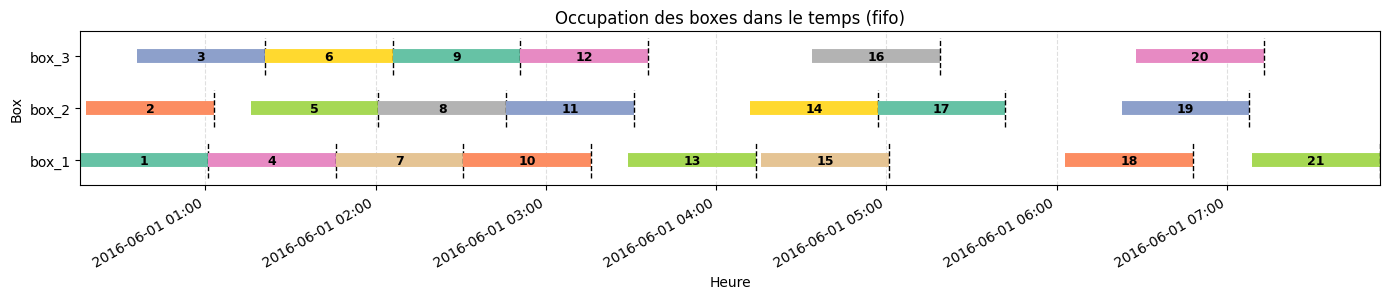

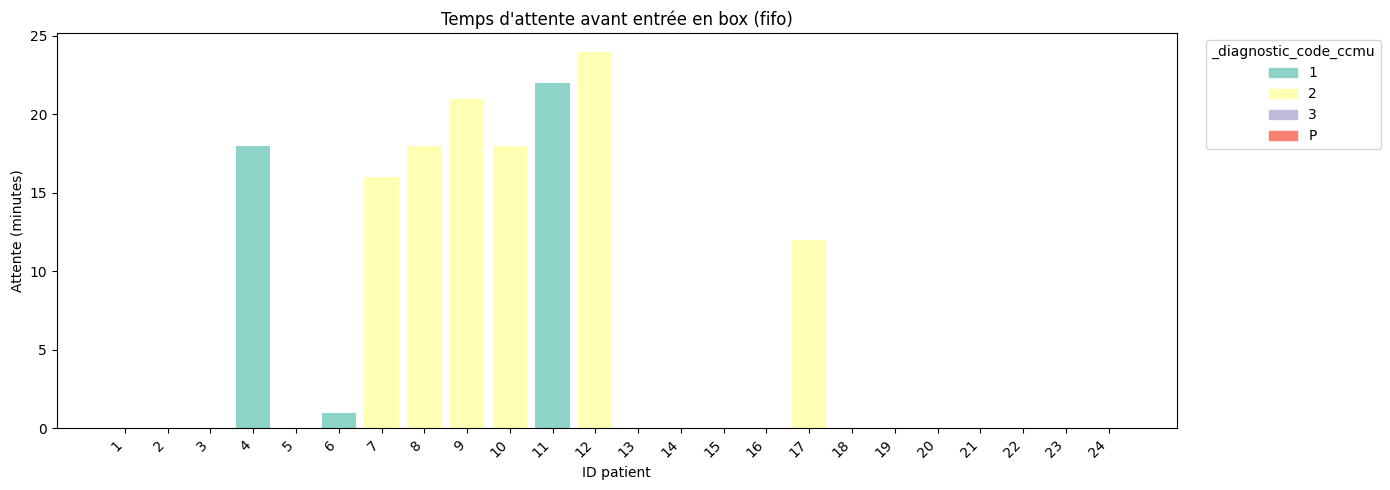

In [86]:
outputs = run_simulation_from_csv(
    csv_path="df_analyse_amont.csv",
    start="2016-06-01 00:00:00",
    end="2016-06-01 08:00:00",
    n_boxes=3,
    box_service_minutes=45,
    mode_ordonnancement="fifo",
    ordonner_fn=ordonner
)

recap = make_recap_df(
    patients_window=outputs["patients_window"],
    sorties_salle_attente=outputs["sorties_salle_attente"],
    services=outputs["services"],
    params=outputs["params"]
)

show_tables(outputs, recap)
plot_boxes_occupation(outputs["services"], outputs["params"].mode_ordonnancement)
plot_waiting_time_bars(outputs["patients_window"], outputs["sorties_salle_attente"], outputs["params"].mode_ordonnancement)